# [TỐI ƯU HÓA] DỰ ÁN AI PHÂN LOẠI XE ĐẠP VÀ XE MÁY (TENSORFLOW/KERAS)

Notebook này bao gồm toàn bộ quá trình tải dữ liệu, chia tập Train/Val/Test phân tầng 100% giống PyTorch, thiết kế ResNet50, huấn luyện và vẽ ma trận nhầm lẫn.\n\n**Lưu ý**: Phiên bản này đã được tinh chỉnh để chống Overfitting (Giảm LR xuống 1e-5, Unfreeze từ layer 150, tăng RandomRotation lên 0.1).

## CELL 1: Cài đặt thư viện và Quét thư mục ảnh gốc
Tải thư viện và duyệt từng ảnh để phân tích, sẵn sàng chia tách.

In [1]:
%pip install -q kagglehub scikit-learn seaborn matplotlib
import os
import kagglehub

# 1. Tải Dataset từ Kaggle
path = kagglehub.dataset_download('nqa112/vietnamese-bike-and-motorbike')
print('Đường dẫn tải dataset gốc:', path)

motor_aliases = ['motorbike', 'motor', 'xe may', 'xe_may']
bike_aliases = ['bike', 'xe dap', 'xe_dap', 'bicycle']

all_paths = []
all_labels = [] # 0: Bike, 1: Motorbike

for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, path).lower()
            
            if any(alias in rel_path for alias in motor_aliases):
                all_paths.append(full_path)
                all_labels.append(1)
            elif any(alias in rel_path for alias in bike_aliases):
                all_paths.append(full_path)
                all_labels.append(0)

print(f"Tổng số ảnh thu thập được: {len(all_paths)}")

Using Colab cache for faster access to the 'vietnamese-bike-and-motorbike' dataset.
Đường dẫn tải dataset gốc: /kaggle/input/vietnamese-bike-and-motorbike
Tổng số ảnh thu thập được: 12118


## CELL 2: Chia phân tầng dữ liệu (Stratified Split)
Áp dụng kỹ thuật tách mảng y hệt phiên bản cũ: 20% Test, từ 80% còn lại lấy tiếp 20% Val và 80% Train. Tỉ lệ từng tập được bảo toàn cực chuẩn.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

# Lần 1: Cắt 20% làm Test Set, 80% còn lại là TrainVal
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=42
)

# Lần 2: Từ 80% TrainVal, cắt 20% làm Validation (16% tổng), 80% làm Train (64% tổng)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=0.20, stratify=trainval_labels, random_state=42
)

class_names = ['Bike', 'Motorbike']

def print_distribution(name, labels):
    labels_np = np.array(labels)
    bike_count = np.sum(labels_np == 0)
    motor_count = np.sum(labels_np == 1)
    total = len(labels)
    print(f"- Tập {name:<10}: {total} ảnh ({bike_count} Bike, {motor_count} Motorbike) - Tỉ lệ: {total/len(all_paths)*100:.1f}%")

print("PHÂN BỔ DỮ LIỆU:")
print_distribution("Train", train_labels)
print_distribution("Validation", val_labels)
print_distribution("Test", test_labels)

PHÂN BỔ DỮ LIỆU:
- Tập Train     : 7755 ảnh (3870 Bike, 3885 Motorbike) - Tỉ lệ: 64.0%
- Tập Validation: 1939 ảnh (967 Bike, 972 Motorbike) - Tỉ lệ: 16.0%
- Tập Test      : 2424 ảnh (1209 Bike, 1215 Motorbike) - Tỉ lệ: 20.0%


## CELL 3: Khởi tạo Băng chuyền `tf.data.Dataset`
Quy hoạch cách đọc ảnh, ép buộc tất cả thành RGB và chuẩn hóa size về 224x224 một cách song song trên GPU.

In [3]:
import tensorflow as tf

def process_path(file_path, label):
    # Đọc file nhị phân
    img = tf.io.read_file(file_path)
    # [QUAN TRỌNG] Giải mã và ép buộc trả về đúng 3 kênh màu RGB (RGB check)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    # Resize chuẩn 224x224 cho ResNet
    img = tf.image.resize(img, [224, 224])
    return img, label

batch_size = 32

def create_dataset(paths, labels, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    # Nếu là tập train thì xáo trộn ngẫu nhiên
    if is_training:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    # Áp dụng hàm đọc ảnh song song
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    # Đóng gói thành các Batch
    ds = ds.batch(batch_size)
    # Nạp trước vào RAM để GPU không phải chờ
    ds = ds.apply(tf.data.experimental.ignore_errors())
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = create_dataset(train_paths, train_labels, is_training=True)
val_dataset = create_dataset(val_paths, val_labels)
test_dataset = create_dataset(test_paths, test_labels)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


## CELL 4: Biến tấu dữ liệu (Data Augmentation)
Thay thế hoàn hảo khối RandomResizedCrop, Rotation, ColorJitter của PyTorch bằng các hàm Keras tương ứng. (Chỉ áp dụng cho đồ thị Train lúc học).

In [4]:
# Khối biến tấu dữ liệu tương tự PyTorch gốc
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.1), # Xoay ±10 độ (10/360)
  tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.0), width_factor=(-0.2, 0.0)), # Phóng to ngẫu nhiên mô phỏng RandomResizedCrop
  tf.keras.layers.RandomContrast(0.2),   # Tương đương ColorJitter(contrast=0.2)
  tf.keras.layers.RandomBrightness(0.2), # Tương đương ColorJitter(brightness=0.2)
], name="data_augmentation")

## CELL 5: Thiết kế Cấu trúc Mô hình (Model Architecture)
Khai báo bộ não ResNet50. Sử dụng cơ chế `preprocess_input` tiêu chuẩn của Keras (hoạt động hoàn hảo với file weights `imagenet`). In ra `Model Summary` lần 1.

In [5]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# ĐÓNG BĂNG BỘ NÃO GỐC
base_model.trainable = False

# ==== THIẾT KẾ MÔ HÌNH ====
inputs = tf.keras.Input(shape=(224, 224, 3), name="input_layer")

# 1. Augmentation trước tiên (không làm hỏng phân bố màu)
x = data_augmentation(inputs)

# 2. Tiền xử lý theo chuẩn Keras (trừ trung bình caffe BGR). 
# Đây là cách chính thống của Keras, chính xác và hiệu quả hơn tự trừ mean/std
x = tf.keras.applications.resnet50.preprocess_input(x)

# 3. Mạng ResNet50
x = base_model(x, training=False) 
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dense(256, activation='relu', name="dense_features")(x)
x = tf.keras.layers.Dropout(0.5, name="dropout_layer")(x)
outputs = tf.keras.layers.Dense(2, name="output_classification")(x)

model = tf.keras.Model(inputs, outputs, name="My_Custom_ResNet50")

print("\n=== CẤU TRÚC MÔ HÌNH TRƯỚC KHI FINE-TUNE ===")
model.summary()


=== CẤU TRÚC MÔ HÌNH TRƯỚC KHI FINE-TUNE ===


Model: "My_Custom_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 256)       │    524,544 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_layer       │ (None, 256)       │          0 │ dense_features[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_classificat… │ (None, 2)         │        514 │ dropout_layer[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## CELL 6: Huấn luyện Giai đoạn 1 (Chỉ dạy lớp phân loại)
Dạy phần cái đầu mới thêm vào.

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("=== BẮT ĐẦU GIAI ĐOẠN 1 ===")
history_stage_1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

=== BẮT ĐẦU GIAI ĐOẠN 1 ===
Epoch 1/10
    243/Unknown 51s 159ms/step - accuracy: 0.9401 - loss: 0.1785

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 209ms/step - accuracy: 0.9675 - loss: 0.1008 - val_accuracy: 0.9911 - val_loss: 0.0196
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 47s 192ms/step - accuracy: 0.9843 - loss: 0.0449 - val_accuracy: 0.9942 - val_loss: 0.0153
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 47s 191ms/step - accuracy: 0.9867 - loss: 0.0366 - val_accuracy: 0.9942 - val_loss: 0.0154
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 74s 305ms/step - accuracy: 0.9874 - loss: 0.0375 - val_accuracy: 0.9953 - val_loss: 0.0103
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 46s 189ms/step - accuracy: 0.9907 - loss: 0.0278 - val_accuracy: 0.9948 - val_loss: 0.0103
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 47s 193ms/step - accuracy: 0.9890 - loss: 0.0294 - val_accuracy: 0.9948 - val_loss: 0.0092
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 47s 195ms/step - accuracy: 0.9896 - loss: 0.0279 - val_accuracy: 0.9979 - val_loss: 0.0073
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 47s 195ms/step - accuracy: 0.9901 - loss: 0.0262 - val

## CELL 7: Tinh chỉnh sâu (Fine-Tuning)
Mở khóa các lớp sâu của bộ não gốc (ResNet50).

In [7]:
base_model.trainable = True

fine_tune_at = 150
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n=== CẤU TRÚC MÔ HÌNH SAU KHI UNFREEZE ĐỂ FINE-TUNE ===")
model.summary()

print("=== BẮT ĐẦU GIAI ĐOẠN 2 (Fine-tuning) ===")

total_epochs = 10 + 15

# [YÊU CẦU CỦA BẠN]: Để mô hình chạy hết toàn bộ số epoch để xem toàn cảnh quá trình học.
# Ta bỏ EarlyStopping (cơ chế dừng ngang) và dùng ModelCheckpoint để lưu lại âm thầm lúc mô hình tốt nhất.
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_keras_model.keras", 
    monitor='val_loss', 
    save_best_only=True
)

history_stage_2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=total_epochs,
    initial_epoch=history_stage_1.epoch[-1] + 1,
    callbacks=[checkpoint]
)

# Vì ta để mô hình chạy hết, những epoch cuối có thể bị quá mức (overfitting).
# Do đó, ta khôi phục lại (load) trọng số ở điểm tốt nhất mà Checkpoint đã lưu.
model.load_weights("best_keras_model.keras")
print("\nĐã lưu và khôi phục bộ não tốt nhất tại best_keras_model.keras")



=== CẤU TRÚC MÔ HÌNH SAU KHI UNFREEZE ĐỂ FINE-TUNE ===


Model: "My_Custom_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 256)       │    524,544 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_layer       │ (None, 256)       │          0 │ dense_features[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_classificat… │ (None, 2)         │        514 │ dropout_layer[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 10,515,202 (40.11 MB)

 Non-trainable params: 13,597,568 (51.87 MB)

=== BẮT ĐẦU GIAI ĐOẠN 2 (Fine-tuning) ===
Epoch 11/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 90s 314ms/step - accuracy: 0.9843 - loss: 0.0488 - val_accuracy: 0.9969 - val_loss: 0.0095
Epoch 12/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 60s 232ms/step - accuracy: 0.9903 - loss: 0.0290 - val_accuracy: 0.9937 - val_loss: 0.0112
Epoch 13/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 93s 383ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9979 - val_loss: 0.0073
Epoch 14/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 112s 260ms/step - accuracy: 0.9937 - loss: 0.0179 - val_accuracy: 0.9990 - val_loss: 0.0043
Epoch 15/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 82s 339ms/step - accuracy: 0.9933 - loss: 0.0170 - val_accuracy: 0.9979 - val_loss: 0.0039
Epoch 16/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 56s 232ms/step - accuracy: 0.9973 - loss: 0.0095 - val_accuracy: 0.9979 - val_loss: 0.0055
Epoch 17/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 56s 229ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9990 - val_loss: 0.0045
Epoch 18/25
243/243 ━━━━━━━━━━━━━

## CELL 8: Vẽ biểu đồ trực quan (Khắc phục lỗi 0.5 Epoch)
Ghép đồ thị, cố định `MaxNLocator` cho trục x chỉ là số nguyên.

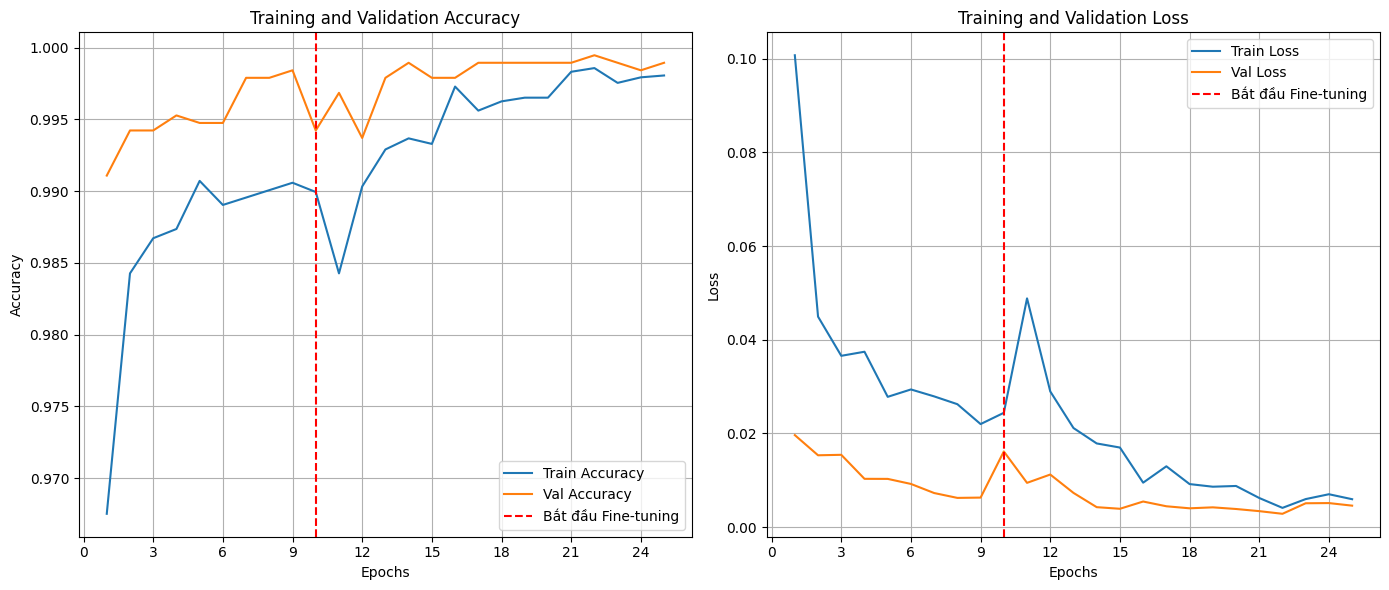

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

acc = history_stage_1.history['accuracy'] + history_stage_2.history['accuracy']
val_acc = history_stage_1.history['val_accuracy'] + history_stage_2.history['val_accuracy']
loss = history_stage_1.history['loss'] + history_stage_2.history['loss']
val_loss = history_stage_1.history['val_loss'] + history_stage_2.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# --- GIẢI THÍCH CƠ CHẾ EARLY STOPPING MỘT CÁCH DỄ HIỂU ---
# Early stopping nhìn vào đường 'val_loss'.
# Nó tìm điểm mà 'val_loss' đạt thấp nhất (tốt nhất). 
# Nếu đi tiếp số bước 'patience' (ở đây là 3) mà 'val_loss' vẫn không phá kỷ lục thấp hơn, nó sẽ lập tức dừng lại!
val_loss_stage_2 = history_stage_2.history['val_loss']
best_epoch_idx = np.argmin(val_loss_stage_2) # Vị trí val_loss thấp nhất ở Giai đoạn 2
patience = 3

# Vị trí giả định bị cắt ngang = Vị trí tốt nhất + patience
hypothetical_stop_idx = best_epoch_idx + patience

# Vị trí thực tế trên đồ thị (cộng thêm 10 epoch của giai đoạn 1)
early_stop_epoch = len(history_stage_1.epoch) + hypothetical_stop_idx + 1

plt.figure(figsize=(14, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(epochs_range, acc, label='Train Accuracy')
ax1.plot(epochs_range, val_acc, label='Val Accuracy')
ax1.axvline(x=10, color='red', linestyle='--', label='Bắt đầu Fine-tuning')

# Vẽ thêm đường cắt của Early Stopping nếu nó thực sự xảy ra trước khi hết epoch
if hypothetical_stop_idx < len(val_loss_stage_2) - 1:
    ax1.axvline(x=early_stop_epoch, color='orange', linestyle=':', linewidth=2, label=f'Early Stop (Epoch {early_stop_epoch})')

ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(epochs_range, loss, label='Train Loss')
ax2.plot(epochs_range, val_loss, label='Val Loss')
ax2.axvline(x=10, color='red', linestyle='--', label='Bắt đầu Fine-tuning')

# Vẽ thêm đường cắt của Early Stopping nếu nó thực sự xảy ra trước khi hết epoch
if hypothetical_stop_idx < len(val_loss_stage_2) - 1:
    ax2.axvline(x=early_stop_epoch, color='orange', linestyle=':', linewidth=2, label=f'Early Stop (Epoch {early_stop_epoch})')

ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('learning_curves_keras.png')
plt.show()


## CELL 9: Đánh giá mô hình trên Test Set (Evaluation)
Sử dụng Tập Test (20%) hoàn toàn chưa từng được nhìn thấy để xuất Báo cáo phân loại (Classification Report) và Ma trận nhầm lẫn (Confusion Matrix).

=== ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (20%) ===

--- Báo cáo phân loại (Classification Report) ---
              precision    recall  f1-score   support

        Bike       1.00      1.00      1.00      1209
   Motorbike       1.00      1.00      1.00      1215

    accuracy                           1.00      2424
   macro avg       1.00      1.00      1.00      2424
weighted avg       1.00      1.00      1.00      2424


--- Ma trận nhầm lẫn (Confusion Matrix) ---


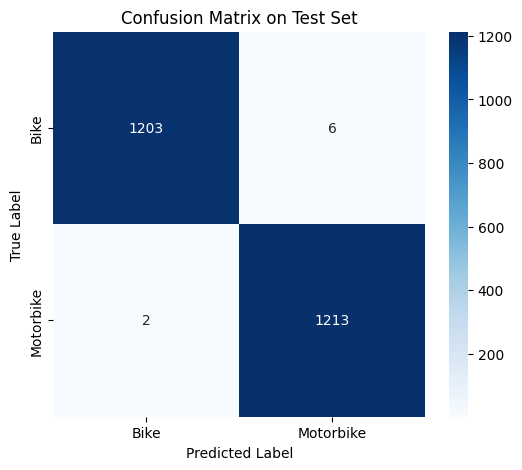

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

print("=== ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (20%) ===")

y_true = []
y_pred_probs = []

# Tắt thanh tiến trình dư thừa của Keras
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)

y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Báo cáo phân loại (Classification Report) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()